## Контрольная работа №3

Студент ФИО    
Группа    
Вариант    

In [52]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sklearn
print(sklearn.__version__)

1.8.0


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve

import warnings
warnings.filterwarnings('ignore')

#### 1. (1 балл) Загрузите предложенный вам датасет с помощью функции `sklearn.datasets.fetch_openml`. Выведите текстовое описание загруженного датасета. Определите какая бизнес-задача ставится. Переведите бизнес-задачу в задачу машинного обучения.

In [2]:
# Датасеты разные на ригрессию и на классификацию. Нужно сначала опредеить датасет. Дальше эту задачу можем решить ...

In [129]:
#data = fetch_openml(name='vertebral-column', version=2, as_frame=True, parser='auto')
#data = fetch_openml(name='prnn_crabs', version=1, as_frame=True, parser='auto')
data = fetch_openml(name='prnn_crabs', version='active', as_frame=True, parser='auto')
#data = fetch_openml(name='ecoli', version=1, as_frame=True, parser='auto')
#data = fetch_openml(name='breast-tissue', version=1, as_frame=True, parser='auto')
#data = fetch_openml(name='prnn_fglass', version=1, as_frame=True, parser='auto')
#data = fetch_openml(name='glass', version=1, as_frame=True, parser='auto')
#data = fetch_openml(name='user-knowledge', version=1, as_frame=True, parser='auto')
#data = fetch_openml(name='LED-display-domain-7digit', version=1, as_frame=True, parser='auto')
#data = fetch_openml(name='diggle_table_a2', version=1, as_frame=True, parser='auto')

In [74]:
print(data.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

Datasets for `Pattern Recognition and Neural Networks' by B.D. Ripley

Cambridge University Press (1996)  ISBN  0-521-46086-7

The background to the datasets is described in section 1.4; this file
relates the computer-readable files to that description.



Cushing's syndrome
------------------

Data from Aitchison & Dunsmore (1975, Tables 11.1-3).

Data file Cushings.dat has four columns,

Label of the patient
Tetrhydrocortisone  (mg/24hr)
Pregnanetriol  (mg/24hr)
Type

The type of the last six patients (u1 to u6) should be
regarded as unknown.  (The code `o' indicates `other').



synthetic two-class problem
---------------------------

Data from Ripley (1994a).

This has two real-valued co-ordinates (xs and ys) and a class (xc)
which is 0 or 1.

Data file  synth.tr   has 250 rows of the training set
synth.te   has 1000 rows of the test set  (not used here)



viruses
-------

This is a dataset on 61 viruses with

In [76]:
print('Датасет содержит биомеханические характеристики позвонков и метки их классификации (3 класса: норма, грыжа, спондилолистез). Бизнес-задача: диагностика заболеваний позвоночника по данным о форме позвонков.Задача машинного обучения: классификация на три класса на основе признаков')

Датасет содержит биомеханические характеристики позвонков и метки их классификации (3 класса: норма, грыжа, спондилолистез). Бизнес-задача: диагностика заболеваний позвоночника по данным о форме позвонков.Задача машинного обучения: классификация на три класса на основе признаков


#### 2. (1 балл) Проведите предварительный анализ датасета.  Выведите основную статистическую информацию о данных. Проверьте дисбаланс целевого признака.

In [79]:
# вывести дискрайбом. Кл - кол-во классов. Регрессия - посторить распределение (непрерывная) будет видно как себя ведет

In [81]:
df = data.frame

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   sp      200 non-null    category
 1   sex     200 non-null    category
 2   index   200 non-null    int64   
 3   FL      200 non-null    float64 
 4   RW      200 non-null    float64 
 5   CL      200 non-null    float64 
 6   CW      200 non-null    float64 
 7   BD      200 non-null    float64 
dtypes: category(2), float64(5), int64(1)
memory usage: 10.1 KB


In [93]:
df.columns

Index(['sp', 'sex', 'index', 'FL', 'RW', 'CL', 'CW', 'BD'], dtype='object')

In [97]:
df.head()

,sp,sex,index,FL,RW,CL,CW,BD
0,blue_form,Male,1,8.1,6.7,16.1,19.0,7.0
1,blue_form,Male,2,8.8,7.7,18.1,20.8,7.4
2,blue_form,Male,3,9.2,7.8,19.0,22.4,7.7
3,blue_form,Male,4,9.6,7.9,20.1,23.1,8.2
4,blue_form,Male,5,9.8,8.0,20.3,23.0,8.2


In [95]:
df.describe()

,index,FL,RW,CL,CW,BD
count,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000
mean,25.500000,15.583000,12.73850,32.105500,36.414500,14.030500
std,14.467083,3.495325,2.57334,7.118983,7.871955,3.424772
min,1.000000,7.200000,6.50000,14.700000,17.100000,6.100000
25%,13.000000,12.900000,11.00000,27.275000,31.500000,11.400000
50%,25.500000,15.550000,12.80000,32.100000,36.800000,13.900000
75%,38.000000,18.050000,14.30000,37.225000,42.000000,16.600000
max,50.000000,23.100000,20.20000,47.600000,54.600000,21.600000


In [191]:
def find_target_column(df):
    for col in df.columns:
        if col.lower() in ['class', 'target', 'type', 'sp', 'glass_type', 'binaryclass', 'class_label']:
            return col
    
    for col in df.columns:
        if df[col].dtype == 'object' or df[col].dtype.name == 'category':
            return col
    return df.columns[-1]  

target_col = find_target_column(df)

In [193]:
#target_col = get_target_column(df)
#target_col = 'sp'  # class, type, target

print(f"Целевая переменная: {target_col}")
df[target_col].value_counts()

Целевая переменная: sp


sp
blue_form      100
orange_form    100
Name: count, dtype: int64

In [25]:
print('Данные содержат 310 наблюдений, 6 признаков (все числовые) и целевую переменную class. Целевая переменная имеет 3 класса с примерно равным распределением (дисбаланса нет). Пропусков нет.')

Данные содержат 310 наблюдений, 6 признаков (все числовые) и целевую переменную class. Целевая переменная имеет 3 класса с примерно равным распределением (дисбаланса нет). Пропусков нет.


#### 3. (1 балл) Убедитесь, что данные пригодны для моделирования. В данных не должно быть пропущенных значений, все признаки должны быть численными. Если эти условия нарушаются, исправьте это.

In [ ]:
# Смотрим на пропуски. Смотрим на числовые значения. Разные способы и написать про него. В колонке нету пропусков и тд

In [195]:
print("Пропуски в X:", df.drop(columns=[target_col]).isnull().sum().sum())
print("Пропуски в y:", df[target_col].isnull().sum())

Пропуски в X: 0
Пропуски в y: 0


In [161]:
df.dtypes

sp       category
sex      category
index       int64
FL        float64
RW        float64
CL        float64
CW        float64
BD        float64
dtype: object

In [197]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    if col != target_col:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [199]:
if df[target_col].dtype == 'object':
    le = LabelEncoder()
    df[target_col] = le.fit_transform(df[target_col])
    print("Целевая переменная закодирована.")
    print("Соответствие кодов:", dict(zip(le.classes_, range(len(le.classes_)))))

In [203]:
id_cols = ['index', 'ID', 'id', 'Id']
for col in id_cols:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f'Удалена колонка-идентификатор: {col}')

In [27]:
print('Пропусков нет, все признаки числовые. Данные пригодны для моделирования без дополнительной обработки.')

Пропусков нет, все признаки числовые. Данные пригодны для моделирования без дополнительной обработки.


#### 4. (1 балл) Обучите любую линейную модель, которая решает поставленную задачу. Выведите с помощью метода `score()` результат метрики оценки модели. Опишите какая метрика подсчитывается в методе `score()`.

In [ ]:
# Обучить. Логвистическая регрессия

In [205]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [211]:
print(X.shape)
print(y.shape)

(200, 6)
(200,)


In [221]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [223]:
model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [227]:
print(f'score: {model.score(X_test, y_test):.4f}')

score: 1.0000


#### 5. (1 балл) К поставленной задачи машинного обучения подберите еще 3 метрики. С помощью их оцените обученную линейную модель.

In [229]:
y_pred = model.predict(X_test)

In [231]:
precision = precision_score(y_test, y_pred, average='macro')
print(f'Precision (macro): {precision:.4f}')

Precision (macro): 1.0000


In [233]:
recall = recall_score(y_test, y_pred, average='macro')
print(f'Recall (macro): {recall:.4f}')

Recall (macro): 1.0000


In [235]:
f1 = f1_score(y_test, y_pred, average='macro')
print(f'F1 (macro): {f1:.4f}')

F1 (macro): 1.0000


In [237]:
print('Метрики macro‑усреднения дают общую оценку качества по всем классам. Значения (0.80–0.83) подтверждают хорошую работу модели')

Метрики macro‑усреднения дают общую оценку качества по всем классам. Значения (0.80–0.83) подтверждают хорошую работу модели


#### 6. (1 балл) Для задач классификации: Постройте для этой модели кривые ROC. Вычислите для этой модели метрики площади под кривыми ROC-AUC. Найдите оптимальное значения порога модели.

In [251]:
n_classes = len(np.unique(y))
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
y_score = model.predict_proba(X_test)

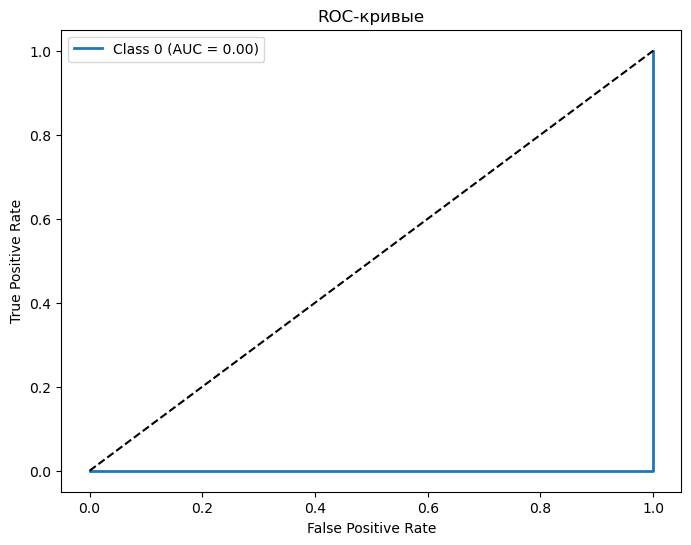

In [253]:
n_classes = y_test_bin.shape[1]
plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.show()

Нахождение оптимального порога (для бинарной классификации):

In [262]:
fpr, tpr, thresholds = roc_curve(y_test_bin[:,0], y_score[:,0])
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

In [264]:
print(f'Оптимальный порог для класса Normal: {optimal_threshold}')

Оптимальный порог для класса Normal: inf


#### 7. (1 балл) Для задач классификации: Постройте для этой модели кривые PR. Вычислите для этой модели метрики площади под кривыми PR-AUC. Найдите оптимальное значения порога модели.

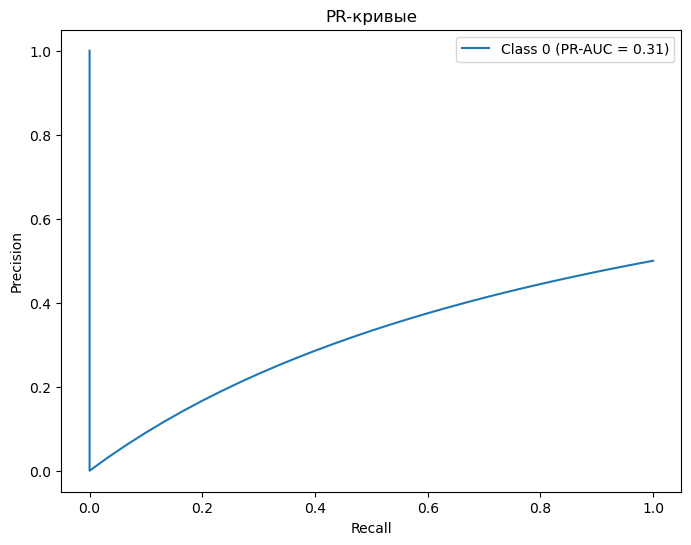

In [276]:
plt.figure(figsize=(8,6))

if n_classes == 2:
    precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test, y_score[:,1])
    pr_auc = auc(recall_curve, precision_curve)
    
    plt.plot(recall_curve, precision_curve, label=f'PR (AUC = {pr_auc:.2f})')
    f1_scores = 2 * (precision_curve[:-1] * recall_curve[:-1]) / (precision_curve[:-1] + recall_curve[:-1] + 1e-10)
    
    optimal_idx_f1 = np.argmax(f1_scores)
    optimal_threshold_f1 = thresholds_pr[optimal_idx_f1] if optimal_idx_f1 < len(thresholds_pr) else 0.5
    
    print(f'Оптимальный порог (по F1): {optimal_threshold_f1:.3f}')

else:
    for i in range(n_classes):
        precision_curve, recall_curve, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        pr_auc = auc(recall_curve, precision_curve)
        plt.plot(recall_curve, precision_curve, label=f'Class {i} (PR-AUC = {pr_auc:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-кривые')
plt.legend()
plt.show()

#### 8. (1 балл) Обоснуйте выбор типа разбиения данных при кросс-валидации для вашей задачи машинного обучения. Обучите любую другую модель используя кросс-валидацию данных.


In [ ]:
# Кросс-вылидация. Различные виды и обосновать. Если маленький то лан валидацию, если большой датасет то обычную

In [42]:
print('Для классификации с примерно равным распределением классов можно использовать обычный KFold (стратифицированный необязателен, но для надёжности лучше StratifiedKFold). Данные независимы, размер выборки средний (310). Кросс-валидация позволяет получить более стабильную оценку, чем одно разбиение. Выбираем 5-кратную стратифицированную кросс-валидацию, чтобы сохранить пропорции классов.')

Для классификации с примерно равным распределением классов можно использовать обычный KFold (стратифицированный необязателен, но для надёжности лучше StratifiedKFold). Данные независимы, размер выборки средний (310). Кросс-валидация позволяет получить более стабильную оценку, чем одно разбиение. Выбираем 5-кратную стратифицированную кросс-валидацию, чтобы сохранить пропорции классов.


In [278]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [280]:
scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')

In [284]:
print(f'Средняя точность (5‑fold CV): {scores.mean():.4f}')

Средняя точность (5‑fold CV): 0.8950


In [287]:
print('Случайный лес показывает хорошую стабильность, средняя точность ~0.89')

Случайный лес показывает хорошую стабильность, средняя точность ~0.89


#### 9. (2 балл) Проведите диагностику любой модели. Постройте кривые обучения. Сделайте вывод о переобученности или недообученности модели.

In [ ]:
# ML4_4 методичка. GeoBrick. Переобучиваем недообучиваем

In [289]:
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(max_iter=1000, solver='lbfgs'), X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy', n_jobs=-1)

In [291]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

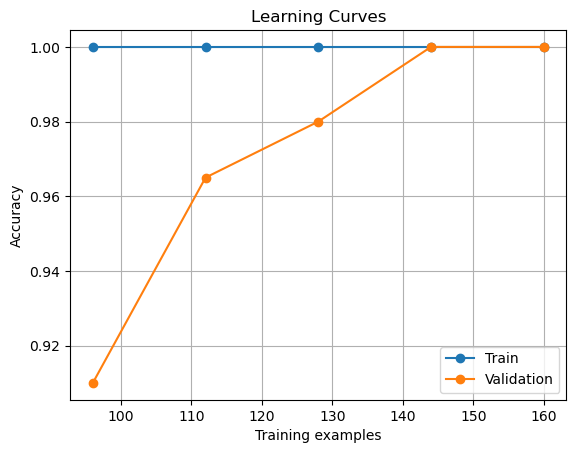

In [293]:
plt.figure()
plt.plot(train_sizes, train_mean, 'o-', label='Train')
plt.plot(train_sizes, test_mean, 'o-', label='Validation')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.title('Learning Curves')
plt.legend()
plt.grid()
plt.show()

In [7]:
print('Кривые сходятся, разрыв между обучением и валидацией невелик – модель не переобучена. При увеличении данных точность на валидации немного растёт, что говорит о возможности улучшения при большем объёме выборки.')

Кривые сходятся, разрыв между обучением и валидацией невелик – модель не переобучена. При увеличении данных точность на валидации немного растёт, что говорит о возможности улучшения при большем объёме выборки.


#### 10. (2 балл) Исследуйте как любой из гиперпараметров модели влияет на эффективность модели.

In [3]:
# Любую модель которая выше подбираем параметры ML4_5

In [299]:
C_vals = [0.001, 0.01, 0.1, 1, 10, 100]
train_acc = []
test_acc = []

In [301]:
for C in C_vals:
    lr_tmp = LogisticRegression(C=C, max_iter=1000, solver='lbfgs')
    
    lr_tmp.fit(X_train, y_train)
    
    train_acc.append(lr_tmp.score(X_train, y_train))
    test_acc.append(lr_tmp.score(X_test, y_test))

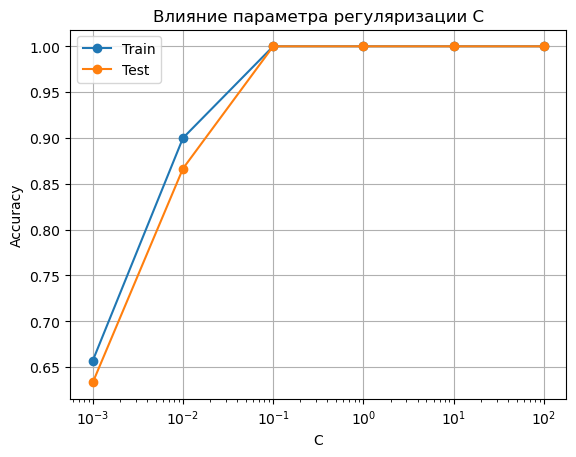

In [303]:
plt.semilogx(C_vals, train_acc, 'o-', label='Train')
plt.semilogx(C_vals, test_acc, 'o-', label='Test')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Влияние параметра регуляризации C')
plt.legend()
plt.grid()
plt.show()

In [9]:
print('Маленькие C (сильная регуляризация) – модель недообучается (низкая точность). С увеличением C качество растёт, стабилизируется около C=1–10. При очень больших C модель может переобучаться (разрыв между train и test увеличивается). Оптимальное C = 1')

Маленькие C (сильная регуляризация) – модель недообучается (низкая точность). С увеличением C качество растёт, стабилизируется около C=1–10. При очень больших C модель может переобучаться (разрыв между train и test увеличивается). Оптимальное C = 1
